<a href="https://colab.research.google.com/github/hashemwa/CSE-482-Project/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.probability import FreqDist
from collections import Counter
from nltk.util import bigrams
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from string import punctuation

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\denni\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\denni\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
df = pd.read_csv('twitter_training.csv', names=['tweet_id', 'subject', 'sentiment', 'review_text'])

# Data Cleaning

In [4]:
## Cleaning

ENGLISH_STOPWORDS_SET = set(stopwords.words('english'))

def remove_stopwords_from_list(token_list):
    """
    Filters a list of tokens, returning only those not in the stopword set.
    """
    # This list comprehension is the efficient way to filter tokens
    return [word for word in token_list if word not in ENGLISH_STOPWORDS_SET]

def remove_punctuation_from_list(token_list):
    """
    Filters a list of tokens, returning only those not in the stopword set.
    """
    # This list comprehension is the efficient way to filter tokens
    return [word for word in token_list if word not in punctuation]

df = df[df["sentiment"].isin(["Positive", "Negative"])]

df["review_text"] = df["review_text"].astype("string")

df["cleaned_text"] = df["review_text"].str.lower()

df = df.dropna(subset= ["cleaned_text"])

# Remove whitespace
df["cleaned_text"] = df["cleaned_text"].str.replace(r'\s+', ' ', regex=True)

df = df.drop_duplicates(subset = ["cleaned_text"])

df["tokens"] = df["cleaned_text"].apply(word_tokenize)

# remove punctuation
df["tokens"] = df["tokens"].apply(remove_punctuation_from_list)

df["tokens"] = df["tokens"].apply(remove_stopwords_from_list)

# Tokenization complete



# Basic Statistics of our Dataset

C:\Users\denni\AppData\Local\Temp\ipykernel_6604\847981992.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pos_df, x="POS", y="Frequency", palette='coolwarm')


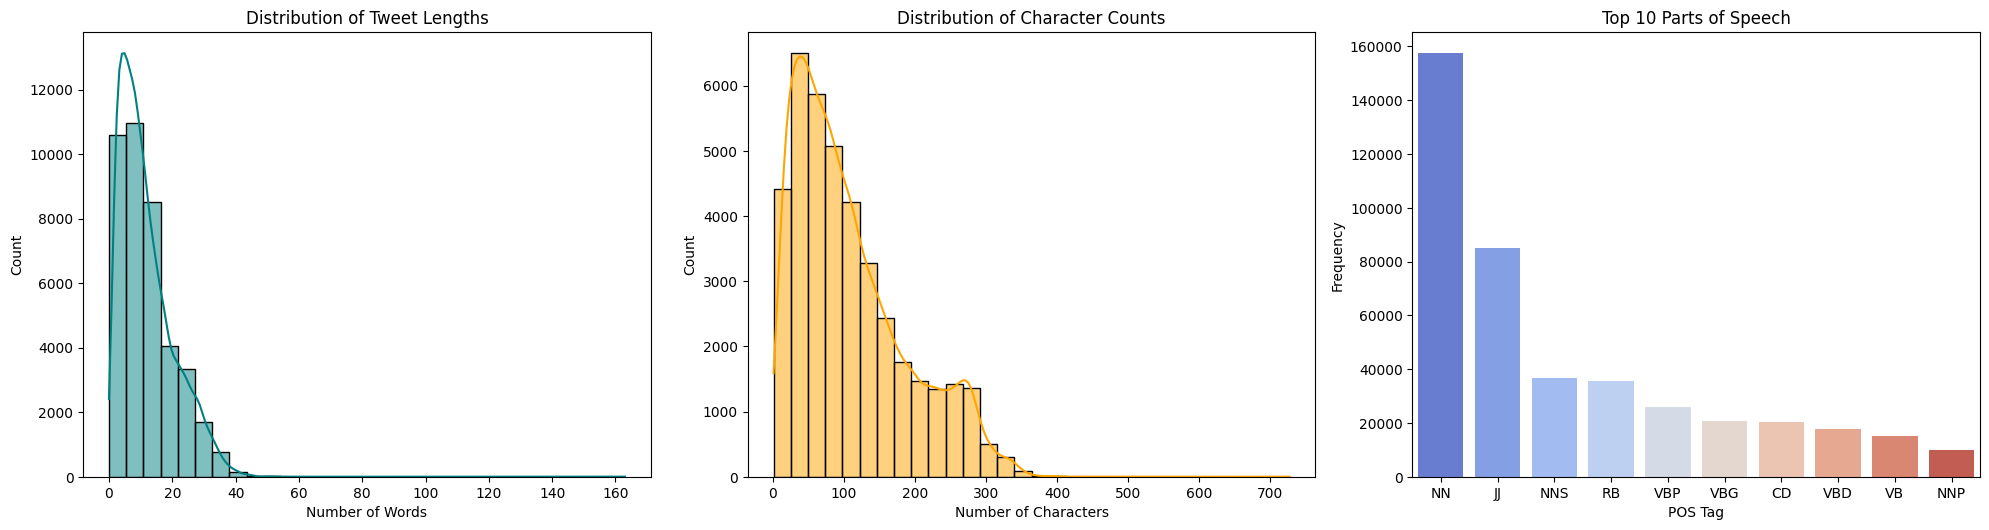

Average Words per Tweet: 11.86


In [20]:
def explore_data_structure(df):

    plt.figure(figsize=(20, 10))

    # 1. Tweet Length (Word Count)
    plt.subplot(2, 3, 1)
    df['doc_len'] = df['tokens'].apply(len)
    sns.histplot(df['doc_len'], bins=30, kde=True, color='teal')
    plt.title('Distribution of Tweet Lengths')
    plt.xlabel('Number of Words')

    # 2. Character Length (Raw Text)
    plt.subplot(2, 3, 2)
    char_len = df['cleaned_text'].str.len()
    sns.histplot(char_len, bins=30, kde=True, color='orange')
    plt.title('Distribution of Character Counts')
    plt.xlabel('Number of Characters')

    # 3. Parts of Speech (POS)
    plt.subplot(2, 3, 3)
    all_tokens = [word for tokens in df['tokens'] for word in tokens]
    pos_tags = nltk.pos_tag(all_tokens)
    pos_freq = FreqDist(tag for (word, tag) in pos_tags)
    pos_df = pd.DataFrame(pos_freq.most_common(10), columns=['POS', 'Frequency'])
    sns.barplot(data=pos_df, x="POS", y="Frequency", palette='coolwarm')
    plt.title('Top 10 Parts of Speech')
    plt.xlabel('POS Tag')

    # 4. Print Summary Stats
    plt.tight_layout()
    plt.show()

    print(f"Average Words per Tweet: {df['doc_len'].mean():.2f}")

explore_data_structure(df)

### N-Gram Generator

In [21]:
## N-gram generator

def get_ngrams(text, n):
  ## I was having issues with NLTK bigrams function. Apparenty it creates generator objects so it doesnt actually calulate the bigrams right away bc of
  ## potential large input. If you guys run into this type of issue, exhause the generator by creating a list().

  return list(nltk.ngrams(text, n))

df["bigrams"] = df["tokens"].apply(lambda tokens: get_ngrams(tokens, 2))

df["trigrams"] = df["tokens"].apply(lambda tokens: get_ngrams(tokens, 3))



# Frequency Distribution of Common Tokens

In [22]:
## EDA
pos_review_t = []
neg_review_t = []

tokens_location = df.columns.get_loc("tokens")
sentiment_location = df.columns.get_loc("sentiment")

for i in range(0, len(df)):
  if df.iloc[i, sentiment_location] == "Negative":
    for word in df.iloc[i, tokens_location]:
      neg_review_t.append(word)

  else:
    for word in df.iloc[i, tokens_location]:
      pos_review_t.append(word)


word_pos_fdist = FreqDist(pos_review_t)

word_neg_fdist = FreqDist(neg_review_t)

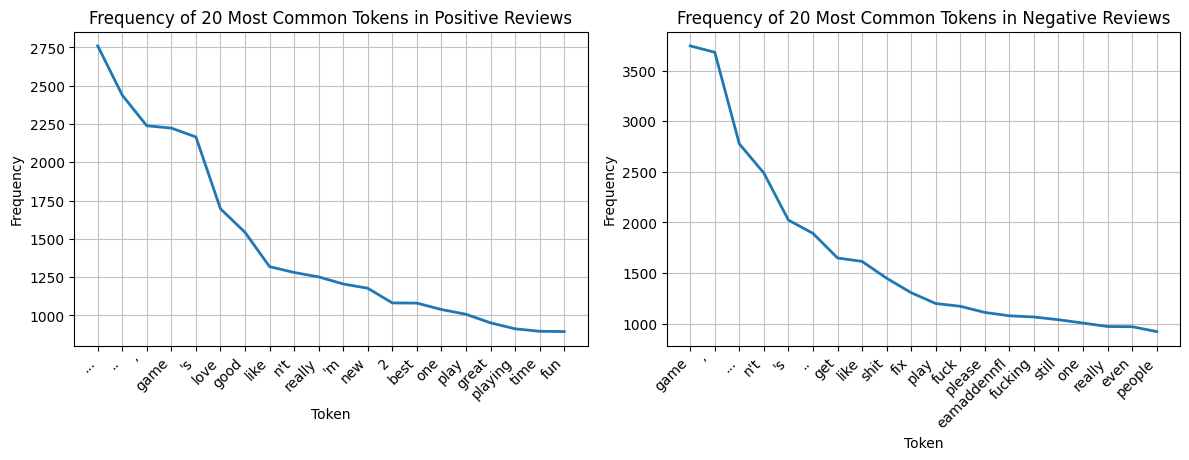

In [23]:
plt.figure(figsize = (12, 8))

plt.subplot(2, 2, 1)

word_pos_fdist.plot(20, cumulative = False)
ax1 = plt.gca()
ax1.set_xticklabels(ax1.get_xticklabels(), rotation = 45, ha = "right")
plt.xlabel("Token")
plt.ylabel("Frequency")
plt.title("Frequency of 20 Most Common Tokens in Positive Reviews")

plt.subplot(2, 2, 2)

word_neg_fdist.plot(20, cumulative = False)
ax2 = plt.gca()
ax2.set_xticklabels(ax2.get_xticklabels(), rotation = 45, ha = "right")
plt.xlabel("Token")
plt.ylabel("Frequency")
plt.title("Frequency of 20 Most Common Tokens in Negative Reviews")


plt.tight_layout()
plt.show()

# Frequency Distribution for Common Bigrams

In [24]:
pos_review_bigrams = []
neg_review_bigrams = []

bigrams_location = df.columns.get_loc("bigrams")
sentiment_location = df.columns.get_loc("sentiment")

for i in range(0, len(df)):
  if df.iloc[i, sentiment_location] == "Negative":
    for bigram in df.iloc[i, bigrams_location]:
      neg_review_bigrams.append(bigram)

  else:
    for bigram in df.iloc[i, bigrams_location]:
      pos_review_bigrams.append(bigram)


bigram_pos_fdist = FreqDist(pos_review_bigrams)

bigram_neg_fdist = FreqDist(neg_review_bigrams)

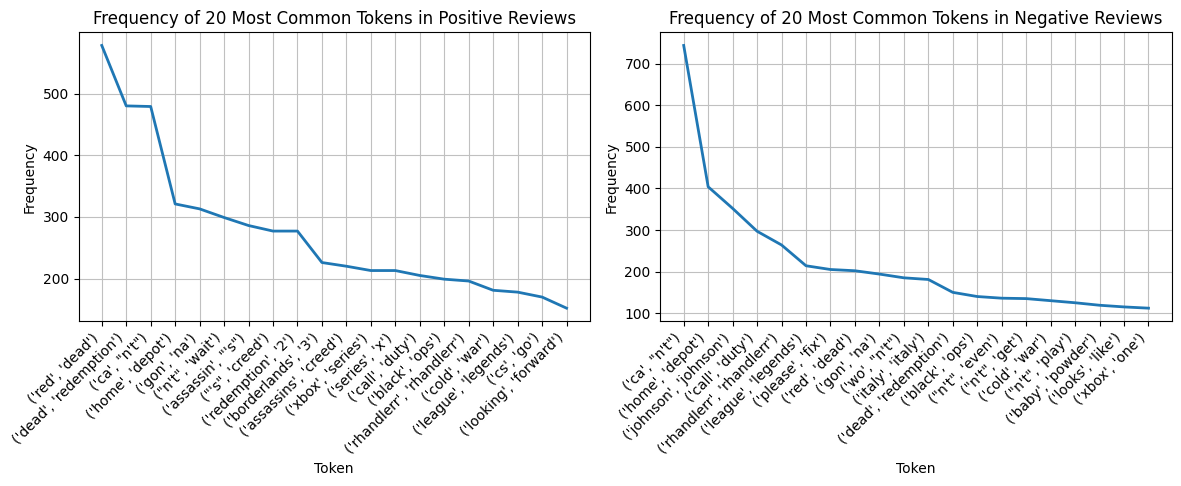

In [25]:
plt.figure(figsize = (12, 8))

plt.subplot(2, 2, 1)

bigram_pos_fdist.plot(20, cumulative = False)
ax1 = plt.gca()
ax1.set_xticklabels(ax1.get_xticklabels(), rotation = 45, ha = "right")
plt.xlabel("Token")
plt.ylabel("Frequency")
plt.title("Frequency of 20 Most Common Tokens in Positive Reviews")

plt.subplot(2, 2, 2)

bigram_neg_fdist.plot(20, cumulative = False)
ax2 = plt.gca()
ax2.set_xticklabels(ax2.get_xticklabels(), rotation = 45, ha = "right")
plt.xlabel("Token")
plt.ylabel("Frequency")
plt.title("Frequency of 20 Most Common Tokens in Negative Reviews")


plt.tight_layout()
plt.show()

# Class Proportion for Most Frequent Bigrams Appearing in Both Classes

In [71]:
## Finding which frequently occuring Bigrams exist in both positive and negative sentiment reviews

from typing import Unpack
pos_neg_duplicate_bigrams = []

top_20_pos_bigrams = bigram_pos_fdist.most_common(20)
top_20_neg_bigrams = bigram_neg_fdist.most_common(20)

bigrams_temp, freq = zip(*top_20_pos_bigrams)
bigrams_temp_list = list(bigrams_temp)

for bigram, count in bigram_neg_fdist.most_common(20):
  if bigram in bigrams_temp_list:
    pos_neg_duplicate_bigrams.append(bigram)


In [72]:
data_to_add = []

for bigram, freq in top_20_pos_bigrams:
  if bigram in pos_neg_duplicate_bigrams:
    new_row = {
        "bigram" : bigram,
        "sentiment" : "Positive",
        "count" : freq
    }

    data_to_add.append(new_row)

for bigram, freq in top_20_neg_bigrams:
  if bigram in pos_neg_duplicate_bigrams:
    new_row = {
        "bigram" : bigram,
        "sentiment" : "Negative",
        "count" : freq
    }

    data_to_add.append(new_row)

df_duplicate_bigrams = pd.DataFrame(data_to_add)

totals = df_duplicate_bigrams.groupby("bigram").agg(
    total = ("count", "sum")
).reset_index()

combined = pd.merge(df_duplicate_bigrams, totals, how = "left", on = "bigram")

combined["proportion"] = round(combined["count"] / combined["total"], 2)

combined = combined.sort_values(by = ["sentiment", "count"], ascending = [False, True])

combined


,bigram,sentiment,count,total,proportion
9,"(cold, war)",Positive,130,311,0.42
8,"(black, ops)",Positive,140,339,0.41
7,"(dead, redemption)",Positive,150,630,0.24
6,"(gon, na)",Positive,194,507,0.38
5,"(red, dead)",Positive,202,780,0.26
4,"(league, legends)",Positive,214,392,0.55
3,"(rhandlerr, rhandlerr)",Positive,264,460,0.57
2,"(call, duty)",Positive,297,502,0.59
1,"(home, depot)",Positive,404,725,0.56
0,"(ca, n't)",Positive,744,1223,0.61


<positron-console-cell-73>:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
<positron-console-cell-73>:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
<positron-console-cell-73>:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
<positron-console-cell-73>:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior).

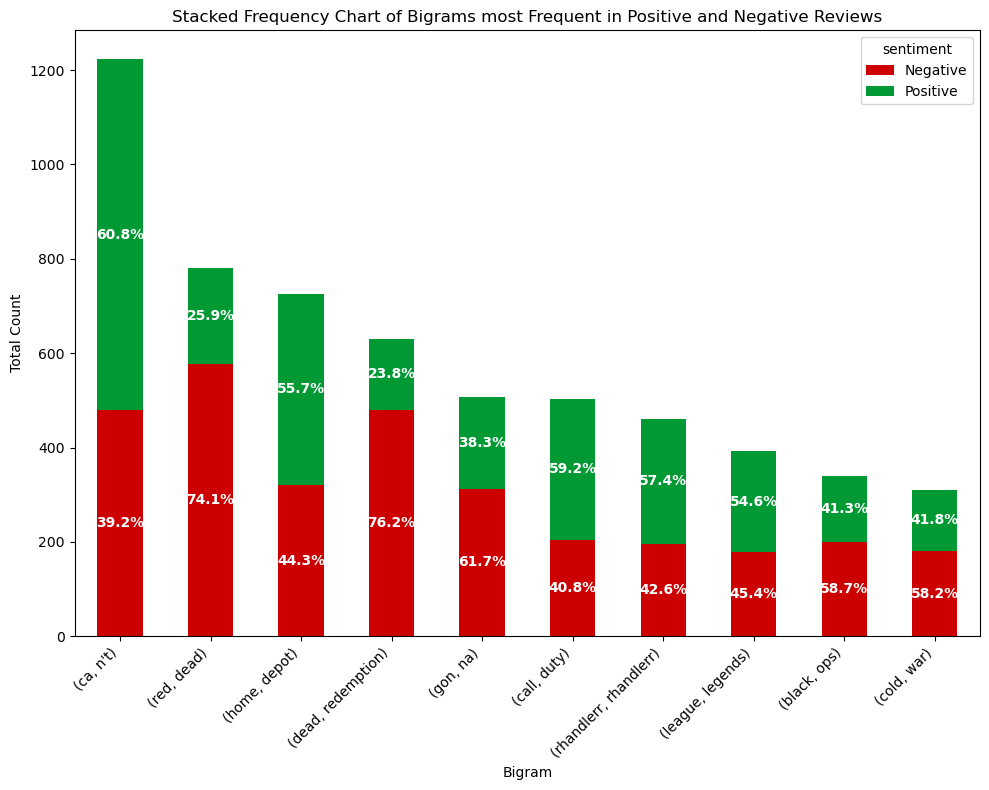

In [73]:
### Bar plot to show proportion of frequency of duplicate bigrams in the top 20 most frequent positive and negative Reviews

#pivot data for stacking
df_pivot = combined.pivot_table(
    index = "bigram",
    columns = "sentiment",
    values = "count"
)

#get index correct order based on total
total_sort_order = combined[["bigram", "total"]].drop_duplicates().sort_values(by = "total", ascending = False)["bigram"]

#reindex pivoted table
df_stack = df_pivot.reindex(total_sort_order)

#create stacked bar plot
ax = df_stack.plot(
    kind = "bar",
    stacked = True,
    figsize= (10, 8),
    color = {"Positive": "#009933", "Negative": "#cc0000"}
)

ax.set_title("Stacked Frequency Chart of Bigrams most Frequent in Positive and Negative Reviews")
ax.set_xlabel("Bigram")
ax.set_ylabel("Total Count")

for container in ax.containers:
    labels = [f"{count / df_stack.sum(axis = 1)[i]:.1%}" if count > 0 else ""
    for i, count in enumerate(container.datavalues)]
    ax.bar_label(container, labels = labels, label_type = "center", color = "white", weight = "bold")

plt.xticks(rotation = 45, ha = "right")
plt.tight_layout()

# TF-IDF Calculations for Both Positive and Negative Reviews

In [74]:
# TF - IDF
df_copy = df
# df_copy.head()

# Split the dataframe by sentiment
df_positive = df_copy[df_copy['sentiment'] == 'Positive'].copy()
df_negative = df_copy[df_copy['sentiment'] == 'Negative'].copy()

print(f"Positive reviews: {len(df_positive)}")
print(f"Negative reviews: {len(df_negative)}")


Positive reviews: 18982
Negative reviews: 21096


In [75]:
from sklearn.feature_extraction.text import TfidfVectorizer


# Function to get top N words using TF-IDF
def get_top_words_tfidf(texts, top_n=10):
    """
    Apply TF-IDF and return top N words
    """
    vectorizer = TfidfVectorizer(
        max_features=200,
        min_df=5,
        max_df=0.95,
        ngram_range=(1, 1),  # Only single words
        stop_words='english'
    )

    # Fit and transform
    tfidf_matrix = vectorizer.fit_transform(texts)
    feature_names = vectorizer.get_feature_names_out()

    # Calculate mean TF-IDF score for each word
    mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()

    # Get top N words
    top_indices = mean_tfidf.argsort()[-top_n:][::-1]

    top_words = pd.DataFrame({
        'word': [feature_names[i] for i in top_indices],
        'tfidf_score': [mean_tfidf[i] for i in top_indices]
    })

    return top_words

# Get top 10 words for positive reviews
print("TOP 10 WORDS - POSITIVE REVIEWS")

top_positive = get_top_words_tfidf(df_positive['cleaned_text'], top_n=10)
print(top_positive)

# Get top 10 words for negative reviews
print("\nTOP 10 WORDS - NEGATIVE REVIEWS")

top_negative = get_top_words_tfidf(df_negative['cleaned_text'], top_n=10)
print(top_negative)

TOP 10 WORDS - POSITIVE REVIEWS
     word  tfidf_score
0    love     0.037408
1    game     0.035968
2    good     0.032816
3     com     0.029577
4    just     0.029036
5    like     0.025026
6    best     0.024757
7  really     0.024143
8     new     0.023847
9     pic     0.022413

TOP 10 WORDS - NEGATIVE REVIEWS
          word  tfidf_score
0         game     0.047784
1         just     0.032990
2         shit     0.028686
3          com     0.026970
4         fuck     0.025211
5         like     0.024432
6  eamaddennfl     0.023523
7          fix     0.022084
8          pic     0.021400
9      verizon     0.021223
          word  tfidf_score
0         game     0.047784
1         just     0.032990
2         shit     0.028686
3          com     0.026970
4         fuck     0.025211
5         like     0.024432
6  eamaddennfl     0.023523
7          fix     0.022084
8          pic     0.021400
9      verizon     0.021223


# Logistic Regression Model Fit using TF-IDF 

Accuracy: 0.7952844311377245
              precision    recall  f1-score   support

           0       0.82      0.78      0.80      4227
           1       0.77      0.81      0.79      3789

    accuracy                           0.80      8016
   macro avg       0.80      0.80      0.80      8016
weighted avg       0.80      0.80      0.80      8016

Confusion Matrix: [[3314  913]
 [ 728 3061]]


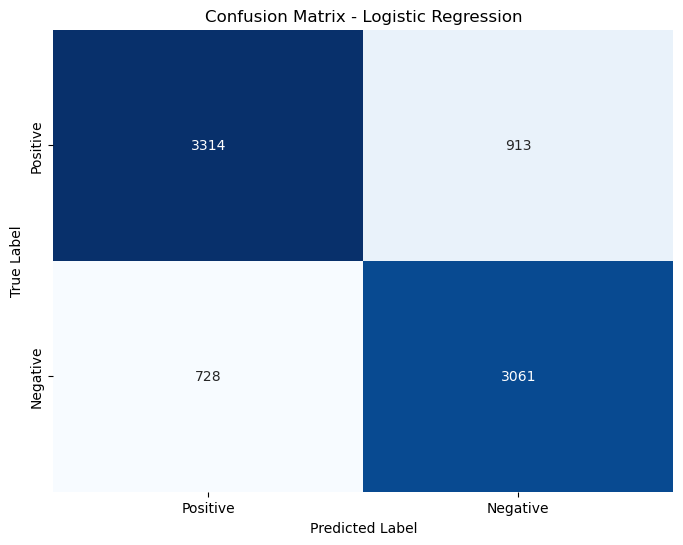

In [76]:
# Logistic Model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Vectorize using TF-IDF
vectorizer = TfidfVectorizer(max_features=500, min_df=5, max_df=0.95, stop_words='english', ngram_range=(1, 2))
X = vectorizer.fit_transform(df['cleaned_text'])
y = (df['sentiment'] == 'Positive').astype(int)


# Split to train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Train
model = LogisticRegression(max_iter=500, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))
print(f"Confusion Matrix: {confusion_matrix(y_test, y_pred)}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Positive", "Negative"],
    yticklabels=["Positive", "Negative"],
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


### Logistic Regression Model Summary

In [77]:
import statsmodels.api as sm
logit_model = sm.Logit(y_train.values.ravel(), sm.add_constant(X_train.toarray()))
result = logit_model.fit()
print(result.summary())

         Current function value: 0.427732
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                32062
Model:                          Logit   Df Residuals:                    31561
Method:                           MLE   Df Model:                          500
Date:                Tue, 25 Nov 2025   Pseudo R-squ.:                  0.3817
Time:                        12:07:38   Log-Likelihood:                -13714.
converged:                      False   LL-Null:                       -22180.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0465      0.039      1.204      0.228      -0.029       0.122
x1             0.4857      0.338      1.436      0.151      -0.17

/Users/wahidhashem/miniforge3/envs/msds/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


# Random Forest Model fit with TF-IDF vs Bag of Words

=== Random Forest Comparison ===

TF-IDF Accuracy: 0.8981
Bag of Words Accuracy: 0.9066


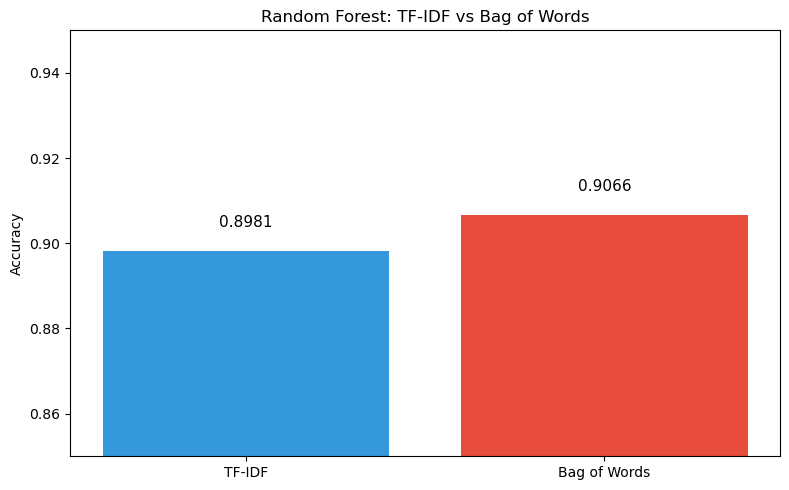

In [78]:
# Random Forest: TF-IDF vs Bag of Words (Constrained)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier

# Prepare target
y = (df['sentiment'] == 'Positive').astype(int)

# TF-IDF vectorization
tfidf_vec = TfidfVectorizer(max_features=500, min_df=5, max_df=0.95, stop_words='english', ngram_range=(1, 2))
X_tfidf = tfidf_vec.fit_transform(df['cleaned_text'])
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# Bag of Words vectorization
bow_vec = CountVectorizer(max_features=500, min_df=5, max_df=0.95, stop_words='english', ngram_range=(1, 2))
X_bow = bow_vec.fit_transform(df['cleaned_text'])
X_train_bow, X_test_bow, _, _ = train_test_split(X_bow, y, test_size=0.2, random_state=42)

# Train Random Forest on TF-IDF
rf_tfidf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf_tfidf.fit(X_train_tfidf, y_train)
acc_tfidf = accuracy_score(y_test, rf_tfidf.predict(X_test_tfidf))

# Train Random Forest on BoW
rf_bow = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf_bow.fit(X_train_bow, y_train)
acc_bow = accuracy_score(y_test, rf_bow.predict(X_test_bow))

print("=== Random Forest Comparison ===\n")
print(f"TF-IDF Accuracy: {acc_tfidf:.4f}")
print(f"Bag of Words Accuracy: {acc_bow:.4f}")

# Bar chart
plt.figure(figsize=(8, 5))
methods = ['TF-IDF', 'Bag of Words']
accuracies = [acc_tfidf, acc_bow]
colors = ['#3498db', '#e74c3c']

bars = plt.bar(methods, accuracies, color=colors)
plt.ylabel('Accuracy')
plt.title('Random Forest: TF-IDF vs Bag of Words')
plt.ylim(0.85, 0.95)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{acc:.4f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

# Random Forest Model fit with Combination of the Bag of Words + TF-IDF

Combined Features: 1000 (TF-IDF: 500 + BoW: 500)

=== Random Forest: Combined Features ===

TF-IDF Only: 0.8981
Bag of Words Only: 0.9066
Combined (TF-IDF + BoW): 0.9024


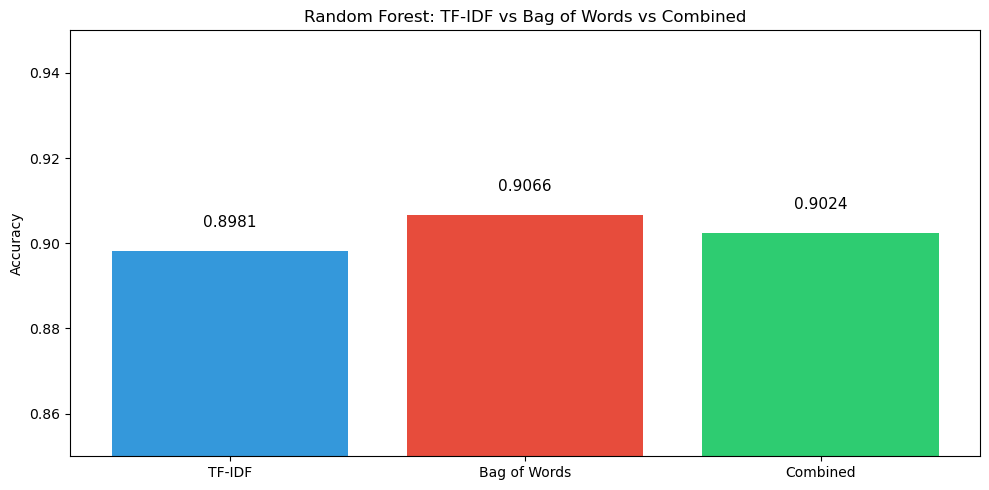

In [79]:
# Random Forest: Combined TF-IDF + Bag of Words
from scipy.sparse import hstack

# Combine TF-IDF and BoW features horizontally
X_combined = hstack([X_tfidf, X_bow])
X_train_combined, X_test_combined, y_train_comb, y_test_comb = train_test_split(
    X_combined, y, test_size=0.2, random_state=42
)

print(f"Combined Features: {X_combined.shape[1]} (TF-IDF: {X_tfidf.shape[1]} + BoW: {X_bow.shape[1]})\n")

# Train Random Forest on combined features
rf_combined = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf_combined.fit(X_train_combined, y_train_comb)
acc_combined = accuracy_score(y_test_comb, rf_combined.predict(X_test_combined))

print("=== Random Forest: Combined Features ===\n")
print(f"TF-IDF Only: {acc_tfidf:.4f}")
print(f"Bag of Words Only: {acc_bow:.4f}")
print(f"Combined (TF-IDF + BoW): {acc_combined:.4f}")

# Bar chart
plt.figure(figsize=(10, 5))
methods = ['TF-IDF', 'Bag of Words', 'Combined']
accuracies = [acc_tfidf, acc_bow, acc_combined]
colors = ['#3498db', '#e74c3c', '#2ecc71']

bars = plt.bar(methods, accuracies, color=colors)
plt.ylabel('Accuracy')
plt.title('Random Forest: TF-IDF vs Bag of Words vs Combined')
plt.ylim(0.85, 0.95)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{acc:.4f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

In [1]:
# # Cross-Validation: Random Forest with TF-IDF, BoW, and Combined
# from sklearn.model_selection import cross_val_score

# print("=== 5-Fold Cross-Validation ===\n")

# # TF-IDF
# cv_tfidf = cross_val_score(
#     RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1),
#     X_tfidf, y, cv=5, scoring='accuracy'
# )
# print(f"TF-IDF: {cv_tfidf.mean():.4f} (+/- {cv_tfidf.std()*2:.4f})")

# # Bag of Words
# cv_bow = cross_val_score(
#     RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1),
#     X_bow, y, cv=5, scoring='accuracy'
# )
# print(f"Bag of Words: {cv_bow.mean():.4f} (+/- {cv_bow.std()*2:.4f})")

# # Combined
# cv_combined = cross_val_score(
#     RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1),
#     X_combined, y, cv=5, scoring='accuracy'
# )
# print(f"Combined: {cv_combined.mean():.4f} (+/- {cv_combined.std()*2:.4f})")

# # Bar chart with error bars
# plt.figure(figsize=(10, 5))
# methods = ['TF-IDF', 'Bag of Words', 'Combined']
# means = [cv_tfidf.mean(), cv_bow.mean(), cv_combined.mean()]
# stds = [cv_tfidf.std(), cv_bow.std(), cv_combined.std()]
# colors = ['#3498db', '#e74c3c', '#2ecc71']

# bars = plt.bar(methods, means, yerr=stds, capsize=5, color=colors)
# plt.ylabel('Accuracy')
# plt.title('Random Forest: 5-Fold Cross-Validation')
# plt.ylim(0.85, 0.95)

# for bar, mean in zip(bars, means):
#     plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015, 
#              f'{mean:.4f}', ha='center', va='bottom', fontsize=11)

# plt.show()

# SVM Model fit with Linear Kernel

In [81]:
### Bag of words implementation

from sklearn.feature_extraction.text import CountVectorizer

model = CountVectorizer(stop_words = "english")

bag_of_words = model.fit_transform(df["cleaned_text"])


In [7]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd # Assuming you need this to handle the target variable

In [83]:
X = bag_of_words
df["sentiment_encoded"] = np.where(df["sentiment"] == "Positive", 1, 0)

y = df["sentiment_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

linear_svm_model = SVC(kernel = "linear", random_state = 42)

linear_svm_model.fit(X_train, y_train)

y_pred = linear_svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

accuracy

0.9333832335329342

In [84]:
from sklearn.metrics import f1_score
svm_confusion_matrix = confusion_matrix(y_test, y_pred)

svm_confusion_matrix

svm_f1score = f1_score(y_test, y_pred, average = "binary")

print(svm_confusion_matrix)
print(svm_f1score)

[[3963  264]
 [ 270 3519]]
0.9294770206022187


### ROC Curve for SVM Model

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate False Positive Rate (FPR), True Positive Rate (TPR), and thresholds
fpr, tpr, tresholds = roc_curve(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_pred)

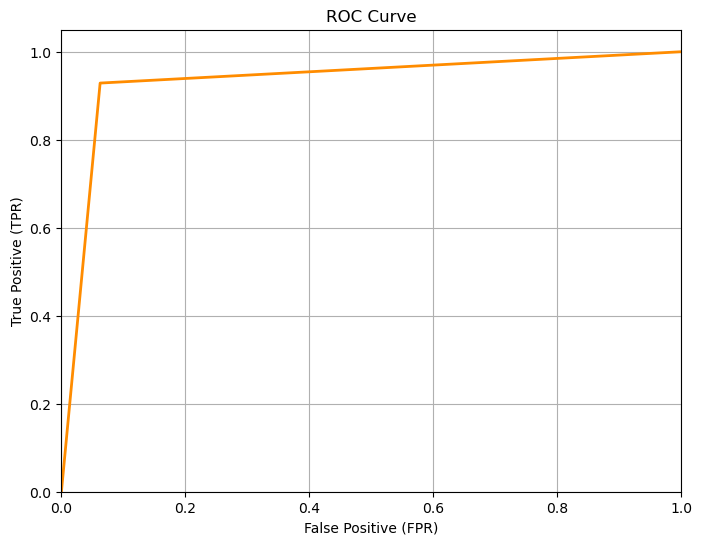

In [86]:
plt.figure(figsize = (8, 6))

plt.plot(fpr, tpr, color = "darkorange", lw = "2",
         label = f"ROC Curve (AUC = {roc_auc:.2f})")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive (FPR)")
plt.ylabel("True Positive (TPR)")
plt.title("ROC Curve")
plt.grid(True)
plt.show()

# Multinomial Bayes Classifier

In [5]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score
from sklearn.feature_extraction.text import CountVectorizer

In [8]:

# Initialize the vectorizer with custom settings
vectorizer_NB = CountVectorizer(
    stop_words='english',
    ngram_range=(1, 2)  # Use both single words and pairs of words
)

X_nb = vectorizer_NB.fit_transform(df['cleaned_text'])
y_nb = (df['sentiment'] == 'Positive').astype(int)

# Split the data into training and testing sets
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_nb, y_nb,
    test_size=0.2,
    random_state=42,
    stratify=y_nb # Ensures the proportion of 'Positive' is maintained in both sets
)

print(f"Training set size: {X_train_nb.shape[0]} reviews")
print(f"Testing set size: {X_test_nb.shape[0]} reviews")


Training set size: 32062 reviews
Testing set size: 8016 reviews


In [9]:
# Initialize the Multinomial Naive Bayes model
# alpha=1.0 is the default (Laplace smoothing) to handle zero probabilities
mnb = MultinomialNB(alpha=1.0)

# Train the model using the training data
mnb.fit(X_train_nb, y_train_nb)

print("Model Training Complete.")

Model Training Complete.


In [13]:
# Make predictions on the test set
y_pred_nb = mnb.predict(X_test_nb)

# Calculate Accuracy
accuracy = accuracy_score(y_test_nb, y_pred_nb)
print(f"\nAccuracy Score: {accuracy:.4f}")

# Print detailed Classification Report
print("\n--- Classification Report ---")
# Target names are defined for clarity: 1 is 'Positive', 0 is 'Other/Negative'
print(classification_report(y_test_nb, y_pred_nb, target_names=['Other/Negative (0)', 'Positive (1)']))



Accuracy Score: 0.9501

--- Classification Report ---
                    precision    recall  f1-score   support

Other/Negative (0)       0.96      0.95      0.95      4219
      Positive (1)       0.94      0.95      0.95      3797

          accuracy                           0.95      8016
         macro avg       0.95      0.95      0.95      8016
      weighted avg       0.95      0.95      0.95      8016



In [17]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import f1_score
# Calculate False Positive Rate (FPR), True Positive Rate (TPR), and thresholds
fpr, tpr, tresholds = roc_curve(y_test_nb, y_pred_nb)

roc_auc = roc_auc_score(y_test_nb, y_pred_nb)

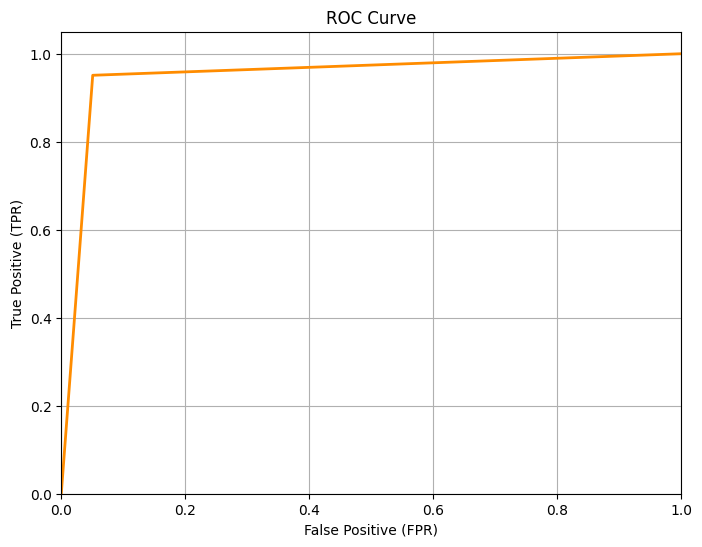

0.9475203358698504


In [18]:
plt.figure(figsize = (8, 6))

plt.plot(fpr, tpr, color = "darkorange", lw = "2",
         label = f"ROC Curve (AUC = {roc_auc:.2f})")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive (FPR)")
plt.ylabel("True Positive (TPR)")
plt.title("ROC Curve")
plt.grid(True)
plt.show()

print(f1_score(y_test_nb, y_pred_nb, average= "binary"))